In [1]:
#!/usr/bin/env python3
'''
CasADi quadrotor simulation using low-fidelity controller
- Low-fidelity quadrotor model
- Simulation using CasADi
- Not translated from modelica version (hand-written)"
'''

'\nCasADi quadrotor simulation using low-fidelity controller\n- Low-fidelity quadrotor model\n- Simulation using CasADi\n- Not translated from modelica version (hand-written)"\n'

In [2]:
# import python packages
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp

ModuleNotFoundError: No module named 'casadi'

Utility functions

In [ ]:
def eul2quat(euler):
    quat = ca.vertcat(ca.cos(euler[2]/2)*ca.cos(euler[1]/2)*ca.cos(euler[0]/2)+ca.sin(euler[2]/2)*ca.sin(euler[1]/2)*ca.sin(euler[0]/2),
                      ca.cos(euler[2]/2)*ca.cos(euler[1]/2)*ca.sin(euler[0]/2)-ca.sin(euler[2]/2)*ca.sin(euler[1]/2)*ca.cos(euler[0]/2),
                      ca.cos(euler[2]/2)*ca.sin(euler[1]/2)*ca.cos(euler[0]/2)+ca.sin(euler[2]/2)*ca.cos(euler[1]/2)*ca.sin(euler[0]/2),
                      ca.sin(euler[2]/2)*ca.cos(euler[1]/2)*ca.cos(euler[0]/2)-ca.cos(euler[2]/2)*ca.sin(euler[1]/2)*ca.sin(euler[0]/2))
    return quat

def quat2eul(quat):          
    euler = ca.vertcat(ca.atan2((2*quat[2]*quat[3]+2*quat[0]*quat[1]),(2*(quat[0]**2)+2*(quat[3]**2)-1)),
                       ca.asin(-(2*quat[1]*quat[3]-2*quat[0]*quat[2])),
                       ca.atan2((2*quat[1]*quat[2]+2*quat[0]*quat[3]),(2*(quat[0]**2)+2*(quat[1]**2)-1)))
    return euler

def quat2rot(quat):
    rot = ca.vertcat(ca.horzcat(1-2*(quat[2]*quat[2]+quat[3]*quat[3]), 2*(quat[1]*quat[2]-quat[0]*quat[3]), 2*(quat[1]*quat[3]+quat[0]*quat[2])),
				     ca.horzcat(2*(quat[1]*quat[2]+quat[0]*quat[3]), 1-2*(quat[1]*quat[1]+quat[3]*quat[3]), 2*(quat[2]*quat[3]-quat[0]*quat[1])),
				     ca.horzcat(2*(quat[1]*quat[3]-quat[0]*quat[2]), 2*(quat[2]*quat[3]+quat[0]*quat[1]), 1-2*(quat[1]*quat[1]+quat[2]*quat[2])))
    return rot

def quatinv(quat):
    inv_quat = ca.vertcat(quat[0], -quat[1], -quat[2], -quat[3])
    return inv_quat

def axang2quat(axis,angle):
    quat = ca.vertcat(ca.cos(0.5*angle),
                      axis[0]*ca.sin(0.5*angle),
                      axis[1]*ca.sin(0.5*angle),
                      axis[2]*ca.sin(0.5*angle))
    return quat

def quatmul(q,r):
    mul_quat = ca.vertcat(r[0]*q[0]-r[1]*q[1]-r[2]*q[2]-r[3]*q[3],
                          r[0]*q[1]+r[1]*q[0]-r[2]*q[3]+r[3]*q[2],
                          r[0]*q[2]+r[1]*q[3]+r[2]*q[0]-r[3]*q[1],
                          r[0]*q[3]-r[1]*q[2]+r[2]*q[1]+r[3]*q[0])
    return mul_quat

def normalballrand(ndim,R,nsample):

    u = np.random.rand(1,nsample)*sp.stats.chi2.cdf(R**2,ndim)
    r = sp.stats.chi2.ppf(u,ndim)
    X = np.random.randn(ndim,nsample)
    X = (r*X/np.linalg.norm(X,axis=0)).T
    
    return X

In [ ]:
def if_else_builder(state, cond_branch):
    for i, (cond, branch) in enumerate(reversed(cond_branch)):
        state = ca.if_else(cond, branch, state)
    return state

Quadrotor Lo-Fi Model

In [ ]:
def GS_quadrotor_chassis_LoFi():

	# parameters
	m = ca.SX.sym('m')
	Ixx = ca.SX.sym('Ixx')
	Iyy = ca.SX.sym('Iyy')
	Izz = ca.SX.sym('Izz')
	d_arm = ca.SX.sym('d_arm')
	r_dir = ca.SX.sym('r_dir',4)
	r_pos = ca.SX.sym('r_pos',4)
	k_t = ca.SX.sym('k_t')
	k_m = ca.SX.sym('k_m')
	g = ca.SX.sym('g')
	wind = ca.SX.sym('wind',3)

	p_vect = ca.vertcat(m, Ixx, Iyy, Izz, d_arm, r_dir, r_pos, k_t, k_m, g, wind)

	# states
	xyz = ca.SX.sym('xyz',3)
	uvw = ca.SX.sym('uvx',3)
	quat = ca.SX.sym('quat',4)
	pqr = ca.SX.sym('pqr',3)

	x_vect = ca.vertcat(xyz, uvw, quat, pqr)

	# inputs
	omega = ca.SX.sym('omega',4)
	
	u_vect = ca.vertcat(omega)

	# compute the rotation matrix from quaternion - defined as rotation from I to B
	R = quat2rot(quat)

	# get the inertia matrix
	J = ca.vertcat(ca.horzcat(Ixx, 0, 0),
				   ca.horzcat(0, Iyy, 0),
				   ca.horzcat(0, 0, Izz))
	
    # compute the thrust and moment
	F = k_t*omega**2
	T = -ca.sum1(F)
	M = ca.vertcat(-d_arm*(ca.sin(r_pos[0])*F[0]+ca.sin(r_pos[1])*F[1]+ca.sin(r_pos[2])*F[2]+ca.sin(r_pos[3])*F[3]),
                   d_arm*(ca.cos(r_pos[0])*F[0]+ca.cos(r_pos[1])*F[1]+ca.cos(r_pos[2])*F[2]+ca.cos(r_pos[3])*F[3]),
				   -(k_m/k_t)*(r_dir[0]*F[0]+r_dir[1]*F[1]+r_dir[2]*F[2]+r_dir[3]*F[3]))

	# differential equation
	xyz_dot = R@uvw+wind
	uvw_dot = -ca.cross(pqr,uvw)+1/m*ca.vertcat(0,0,T)+R.T@ca.vertcat(0,0,g)
	quat_dot = 0.5*ca.vertcat(ca.horzcat(0, -pqr[0], -pqr[1], -pqr[2]),
                            ca.horzcat(pqr[0],  0,  pqr[2], -pqr[1]),
                            ca.horzcat(pqr[1], -pqr[2],  0,  pqr[0]),
                            ca.horzcat(pqr[2],  pqr[1], -pqr[0],  0))@quat
	pqr_dot = ca.inv_minor(J)@(-ca.cross(pqr,J@pqr)+M)
    
	dx_vect = ca.vertcat(xyz_dot, uvw_dot, quat_dot, pqr_dot)

	# define differential equation
	f_quad = ca.Function('f', [x_vect, u_vect, p_vect], [dx_vect], ['x', 'u', 'p'], ['dx'])
	
	return f_quad

In [7]:
def GS_quadrotor_sensor_LoFi():

	# parameters
	arm_ins = ca.SX.sym('arm_ins',3)			# lever arm of INS, related to INS_POS_X / INS_POS_Y / INS_POS_Z
	arm_gps = ca.SX.sym('arm_gps',3)			# lever arm of GPS, related to GPS_POS_X / GPS_POS_Y / GPS_POS_Z
	b_acc = ca.SX.sym('b_acc',3)				# bias of accelerometer, related to INS_ACCOFFS_X / INS_ACCOFFS_Y / INS_ACCOFFS_Z
	s_acc = ca.SX.sym('s_acc',3)				# scale factor of accelerometer, related to INS_ACCSCAL_X / INS_ACCSCAL_Y / INS_ACCSCAL_Z
	b_gyro = ca.SX.sym('b_gryo',3)				# bias of gyroscope, related to INS_GYROFFS_X / INS_GYROFFS_Y / INS_GYROFFS_Z
	
	p_vect = ca.vertcat(arm_ins, arm_gps, b_acc, s_acc, b_gyro)

	# inputs
	xyz = ca.SX.sym('xyz',3)
	uvw = ca.SX.sym('uvx',3)
	quat = ca.SX.sym('quat',4)
	pqr = ca.SX.sym('pqr',3)
	d_sensor = ca.SX.sym('d_sensor',13)

	u_vect = ca.vertcat(xyz, uvw, quat, pqr, d_sensor)

	# outputs
	R = quat2rot(quat+d_sensor[6:10])

	xyz_meas = (xyz+d_sensor[0:3])+R@arm_gps
	uvw_meas = (uvw+d_sensor[3:6])+ca.cross((pqr+d_sensor[10:13]),R@arm_gps)
	acc_meas = ca.vertcat(0, 0, 0)
	quat_meas = (quat+d_sensor[6:10])
	pqr_meas = (pqr+d_sensor[10:13])+b_gyro

	y_vect = ca.vertcat(xyz_meas, uvw_meas, quat_meas, pqr_meas)

	# define differential equation
	f_sensor = ca.Function('f', [u_vect, p_vect], [y_vect], ['u', 'p'], ['y'])

	return f_sensor

Quadrotor Model Unit Test

In [8]:
# drone parameters can be obtained from sysID
# using the parameters obtained from sysBOM
# mass: 0.225(chassis)+0.402(batt,top)+0.402(batt,bottom)+0.072x4(motors) = 1.3170
# Inertia: XX = 1/12*(0.225)*(0.19^2+0.02^2)+(1/12*(0.402)*(0.152^2+0.016^2))... = 6.5e-3
#               +(1/12*(0.402)*(0.152^2+0.016^2))+4*(1/4*(0.072)*(0.023)^2+1/12*(0.072)*(0.018)^2+(0.072)*(0.17/sqrt(2))^2)
#          YY = 1/12*(0.225)*(0.115^2+0.02^2)+(1/12*(0.402)*(0.065^2+0.016^2)+(0.402)*0.05^2)... = 6.8e-3
#               +(1/12*(0.402)*(0.065^2+0.016^2)+(0.402)*0.05^2)+4*(1/4*(0.072)*(0.023)^2+1/12*(0.072)*(0.018)^2+(0.072)*(0.17/sqrt(2))^2)
#          ZZ = 1/12*(0.225)*(0.19^2+0.115^2)+(1/12*(0.402)*(0.152^2+0.065^2)+(0.402)*0.05^2)...
#               +(1/12*(0.402)*(0.152^2+0.065^2)+(0.402)*0.05^2)+4*(1/2*(0.072)*(0.023)^2+(0.072)*(0.17)^2) = 1.32e-2
# using the parameters obtained from a similar-level quadrotor
# S. Folk, J. Paulos, and V. Kumar, “RotorPy: A Python-based Multirotor Simulator 
# with Aerodynamics for Education and Research,” 2023.

f_quad = GS_quadrotor_chassis_LoFi()
f_quad([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [761.1116, 761.1116, 761.1116, 761.1116], [1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

dt = 0.01
dae = {'x': f_quad.sx_in(0), 'p': ca.vertcat(f_quad.sx_in(1), f_quad.sx_in(2)), 'ode': f_quad(f_quad.sx_in(0), f_quad.sx_in(1), f_quad.sx_in(2))}
integrator = ca.integrator('integrator', 'rk', dae, 0, dt)

result = integrator(x0=np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]), p=np.array([761.1116, 761.1116, 761.1116, 761.1116, 1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0]))
print(result['xf'][0:6].full().flatten())
print(quat2eul(result['xf'][6:10]).full().flatten()/np.pi*180)

print(quat2rot(eul2quat(ca.vertcat(0, -20/180*np.pi, 0))).T@ca.vertcat(0, 0, 9.8))

[ 9.06682174e-23  9.48529044e-23 -2.01724979e-11  3.62672825e-20
  3.79411571e-20 -4.03449958e-09]
[ 6.65469903e-17 -6.36110936e-17 -3.63812883e-35]
[3.3518, 0, 9.20899]


In [9]:
# check the validity of sensor measurement block
print(eul2quat(ca.vertcat(0/180*np.pi, 90/180*np.pi, 0/180*np.pi)))

f_sensor = GS_quadrotor_sensor_LoFi()
print(f_sensor([0, 0, 0, 0, 0, 0, 0.707107, 0, 0, 0.707107, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))     # (+) yaw 90deg
print(f_sensor([0, 0, 0, 0, 0, 0, 0.707107, 0.707107, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))     # (+) roll 90deg
print(f_sensor([0, 0, 0, 0, 0, 0, 0.707107, 0, 0.707107, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))     # (+) pitch 90deg

print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))        # (+) roll rate 20deg/s
print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))        # (+) pitch rate 20deg/s
print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]))        # (+) yaw rate 20deg/s

print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 10/180*np.pi, 0.0, 0.0]))   # (+) roll rate bias 10deg/s
print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 10/180*np.pi, 0.0]))   # (+) pitch rate bias 10deg/s
print(f_sensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 20/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 10/180*np.pi]))   # (+) yaw rate bias 10deg/s

[0.707107, 0, 0.707107, 0]
[-6.18898e-07, 1, 0, 0, 0, 0, 0.707107, 0, 0, 0.707107, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0.707107, 0.707107, 0, 0, 0, 0, 0]
[-6.18898e-07, 0, -1, 0, 0, 0, 0.707107, 0, 0.707107, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0.349066, 0, 0]
[1, 0, 0, 0, 0, -0.349066, 1, 0, 0, 0, 0, 0.349066, 0]
[1, 0, 0, 0, 0.349066, 0, 1, 0, 0, 0, 0, 0, 0.349066]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0.523599, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0.523599, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0.523599]


Controller Lo-Fi Model

In [ ]:
def GS_controller_LoFi():

	# attack irrelevant parameters
    ANGLE_RATE_MAX = ca.SX.sym('ANGLE_RATE_MAX')
    ACC_MAX_Z = ca.SX.sym('ACC_MAX_Z')
    ANG_RLL_P = ca.SX.sym('ANG_RLL_P')
    ANG_PIT_P = ca.SX.sym('ANG_PIT_P')
    ANG_YAW_P = ca.SX.sym('ANG_YAW_P')
    RAT_RLL_P = ca.SX.sym('RAT_RLL_P')
    RAT_RLL_I = ca.SX.sym('RAT_RLL_I')
    RAT_RLL_D = ca.SX.sym('RAT_RLL_D')
    RAT_PIT_P = ca.SX.sym('RAT_PIT_P')
    RAT_PIT_I = ca.SX.sym('RAT_PIT_I')
    RAT_PIT_D = ca.SX.sym('RAT_PIT_D')
    RAT_YAW_P = ca.SX.sym('RAT_YAW_P')
    RAT_YAW_I = ca.SX.sym('RAT_YAW_I')
    RAT_YAW_D = ca.SX.sym('RAT_YAW_D')
    POS_XYZ_P = ca.SX.sym('POS_XYZ_P')
    VEL_XYZ_P = ca.SX.sym('VEL_XYZ_P')
    VEL_XYZ_I = ca.SX.sym('VEL_XYZ_I')
    VEL_XYZ_D = ca.SX.sym('VEL_XYZ_D')

    FREQ = ca.SX.sym('FREQ')
    MASS = ca.SX.sym('MASS')
    IXX = ca.SX.sym('IXX')
    IYY = ca.SX.sym('IYY')
    IZZ = ca.SX.sym('IZZ')
    D_ARM = ca.SX.sym('D_ARM')
    R_DIR = ca.SX.sym('R_DIR',4)
    R_POS = ca.SX.sym('R_POS',4)
    K_T = ca.SX.sym('K_T')
    K_M = ca.SX.sym('K_M')
    g = ca.SX.sym('g')

    # attack relevant parameters
    # INS_ACCOFFS_X / INS_ACCOFFS_Y / INS_ACCOFFS_Z : Accelerometer offsets of X, Y, Z axes (bias)
    # INS_ACCSCAL_X / INS_ACCSCAL_Y / INS_ACCSCAL_Z : Accelerometer scaling of X, Y, Z axes (scale factor)
    # INS_GYROFFS_X / INS_GYROFFS_Y / INS_GYROFFS_Z : Gyroscope offsets of X, Y, Z axes (bias)
    # INS_POS_X / INS_POS_Y / INS_POS_Z : IMU accelerometer position in body X, Y, Z axes (lever arm to IMU)
    # GPS_POS_X / GPS_POS_Y / GPS_POS_Z : GPS antenna position in body X, Y, Z axes (lever arm to GPS)
    # RC3_MAX / RC3_MIN : Max/Min PWM value in microseconds that will ever be output to the motors
    # ANGLE_MAX : Maximum lean angle in all flight modes

    ANGLE_MAX = ca.SX.sym('ANGLE_MAX')
    INS_ACCOFFS = ca.SX.sym('INS_ACCOFFS',3)
    INS_ACCSCAL = ca.SX.sym('INS_ACCSCAL',3)
    INS_GYROFFS = ca.SX.sym('INS_GYROFFS',3)
    INS_POS = ca.SX.sym('INS_POS',3)
    GPS_POS = ca.SX.sym('GPS_POS',3)
    RC3_BND = ca.SX.sym('RC3_BND',2)

    p_vect = ca.vertcat(ANGLE_MAX, ANGLE_RATE_MAX, ACC_MAX_Z, ANG_RLL_P, ANG_PIT_P, ANG_YAW_P,
                        RAT_RLL_P, RAT_RLL_I, RAT_RLL_D, RAT_PIT_P, RAT_PIT_I, RAT_PIT_D, 
                        RAT_YAW_P, RAT_YAW_I, RAT_YAW_D, POS_XYZ_P, VEL_XYZ_P, VEL_XYZ_I, VEL_XYZ_D,
                        FREQ, MASS, IXX, IYY, IZZ, D_ARM, R_DIR, R_POS, K_T, K_M,
                        INS_ACCOFFS, INS_ACCSCAL, INS_GYROFFS, INS_POS, GPS_POS, RC3_BND, g)

    # controller internal state (hybrid system)
    s = ca.SX.sym('s')
    yaw_target = ca.SX.sym('yaw_target')
    rate_err_last = ca.SX.sym('rate_err_last',3)
    rate_err_int = ca.SX.sym('rate_err_int',3)
    vel_err_last = ca.SX.sym('vel_err_last',3)
    vel_err_int = ca.SX.sym('pos_err_int',3)

    x_vect = ca.vertcat(s, yaw_target, rate_err_last, rate_err_int, vel_err_last, vel_err_int)

	# state feedback inputs
    xyz_fdbk = ca.SX.sym('xyz_fdbk',3)
    uvw_fdbk = ca.SX.sym('uvw_fdbk',3)
    quat_fdbk = ca.SX.sym('quat_fdbk',4)
    pqr_fdbk = ca.SX.sym('pqr_fdbk',3)
     
    u_vect = ca.vertcat(xyz_fdbk, uvw_fdbk, quat_fdbk, pqr_fdbk)

	# reference inputs
    normal_thr_cmd = ca.SX.sym('normal_thr_cmd')
    normal_roll_cmd = ca.SX.sym('normal_roll_cmd')
    normal_pitch_cmd = ca.SX.sym('normal_pitch_cmd')
    normal_yaw_rate_cmd = ca.SX.sym('normal_yaw_rate_cmd')
    wpt_cmd = ca.SX.sym('wpt_cmd',3)

    r_vect = ca.vertcat(normal_thr_cmd, normal_roll_cmd, normal_pitch_cmd, normal_yaw_rate_cmd, wpt_cmd)

    # stick input conversion - add conversion between euler angle and roll/pitch angle
    acc_z_target_manual = normal_thr_cmd*ACC_MAX_Z
    roll_target_manual = normal_roll_cmd*ANGLE_MAX
    pitch_target_manual = normal_pitch_cmd*ANGLE_MAX
    yaw_target_p_manual = yaw_target+normal_yaw_rate_cmd*ANGLE_RATE_MAX

    # compute control command and update controller state (position control loop)   
    pos_target = wpt_cmd

    # compute the position error and update velocity target
    pos_err = pos_target-(xyz_fdbk-GPS_POS)
    vel_target = ca.vertcat(POS_XYZ_P, POS_XYZ_P, POS_XYZ_P)*pos_err

    # compute the velocity error and update acceleration target
    rot_fdbk = quat2rot(quat_fdbk)
    vxyz_fdbk = rot_fdbk@uvw_fdbk
    vel_err = vel_target-vxyz_fdbk

    vel_err_d = (vel_err-vel_err_last)*FREQ
    vel_err_last_p = vel_err
    vel_err_int_p = vel_err_int+vel_err/FREQ

    acc_target_pos_ctrl = ca.vertcat(VEL_XYZ_P, VEL_XYZ_P, VEL_XYZ_P)*vel_err+ca.vertcat(VEL_XYZ_I, VEL_XYZ_I, VEL_XYZ_I)*vel_err_int_p+ca.vertcat(VEL_XYZ_D, VEL_XYZ_D, VEL_XYZ_D)*vel_err_d-ca.vertcat(0.0, 0.0, g)

    # acceleration command conversion
    eul_fdbk = quat2eul(quat_fdbk)
    acc_z_target_pos_ctrl = -acc_target_pos_ctrl[2]
    acc_forward_pos_ctrl = acc_target_pos_ctrl[0]*ca.cos(eul_fdbk[2])+acc_target_pos_ctrl[1]*ca.sin(eul_fdbk[2])
    acc_right_pos_ctrl = -acc_target_pos_ctrl[0]*ca.sin(eul_fdbk[2])+acc_target_pos_ctrl[1]*ca.cos(eul_fdbk[2])
    pitch_target_pos_ctrl = ca.atan(-acc_forward_pos_ctrl/g)
    roll_target_pos_ctrl = ca.atan(acc_right_pos_ctrl*ca.cos(pitch_target_pos_ctrl)/g)
    yaw_target_p_pos_ctrl = 0.0

    # check whether the auto mode is engaged
    acc_z_target = ca.if_else(s == 0, acc_z_target_manual, acc_z_target_pos_ctrl)
    roll_target = ca.if_else(s == 0, roll_target_manual, ca.fmin(ca.fmax(roll_target_pos_ctrl,-ANGLE_MAX),ANGLE_MAX))
    pitch_target = ca.if_else(s == 0, pitch_target_manual, ca.fmin(ca.fmax(pitch_target_pos_ctrl,-ANGLE_MAX),ANGLE_MAX))
    yaw_target_p = ca.if_else(s == 0, yaw_target_p_manual, yaw_target_p_pos_ctrl)

    # compute control command and update controller state (attitude control loop)   
    # attitude target given as the body angle seen from the inertial frame
    attitude_target = eul2quat(ca.vertcat(roll_target,pitch_target,yaw_target_p))

    # compute the desired thrust vector direction in inertial frame
    att_target_thrust_vec = quat2rot(quatinv(attitude_target))@ca.vertcat(0.0, 0.0, -1.0)

    # compute the current thrust vector direction in inertial frame
    att_body_thrust_vec = quat2rot(quatinv(quat_fdbk))@ca.vertcat(0.0, 0.0, -1.0)

    # compute the lean angle using the dot product
    thrust_angle = ca.acos(ca.fmax(ca.fmin(ca.dot(ca.vertcat(0.0, 0.0, -1.0), att_body_thrust_vec), 1), -1))
    # thrust_angle = ca.fmin(ca.fmax(thrust_angle,-ANGLE_MAX),ANGLE_MAX) - Check Ardupilot source code

    # define the rotation vector using the cross product
    thrust_vec_cross_i1 = ca.cross(att_body_thrust_vec, att_target_thrust_vec)

    # compute the error angle between the target and desired thrust vector
    thrust_error_angle = ca.acos(ca.fmax(ca.fmin(ca.dot(att_body_thrust_vec, att_target_thrust_vec), 1), -1))

    # normalize the thrust rotation vector
    thrust_vec_cross_i2 = ca.if_else(ca.logic_or(ca.norm_2(thrust_vec_cross_i1) == 0, thrust_error_angle == 0), ca.vertcat(0, 0, -1), thrust_vec_cross_i1/ca.norm_2(thrust_vec_cross_i1))

    # transform the rotation vector back to body frame and compute roll/pitch error angle
    thrust_vec_cross_b = quat2rot(quat_fdbk)@thrust_vec_cross_i2
    thrust_vector_correction = axang2quat(thrust_vec_cross_b,thrust_error_angle)
    rp_error = quat2eul(thrust_vector_correction)

    # compute the heading error
    heading_vec_correction_quat = quatmul(quatinv(thrust_vector_correction),quatmul(quat_fdbk,quatinv(attitude_target)))
    y_error = quat2eul(heading_vec_correction_quat)

    # augment roll/pitch/yaw error and set target 
    att_err = ca.vertcat(rp_error[0], rp_error[1], y_error[2])
    rate_target = ca.vertcat(ANG_RLL_P, ANG_PIT_P, ANG_YAW_P)*att_err

    # compute the angular velocity error (differentiation/integration)
    rate_err = rate_target-(pqr_fdbk-INS_GYROFFS)

    rate_err_d = (rate_err-rate_err_last)*FREQ
    rate_err_last_p = rate_err
    rate_err_int_p = rate_err_int+rate_err/FREQ

    # compute target thrust
    force_target = MASS*(acc_z_target)/ca.cos(thrust_angle)

    # compute target moment
    J = ca.vertcat(ca.horzcat(IXX, 0, 0),
                   ca.horzcat(0, IYY, 0),
                   ca.horzcat(0, 0, IZZ))

    moment_target = J@(ca.vertcat(RAT_RLL_P, RAT_PIT_P, RAT_YAW_P)*rate_err+ca.vertcat(RAT_RLL_I, RAT_PIT_I, RAT_YAW_I)*rate_err_int_p+ca.vertcat(RAT_RLL_D, RAT_PIT_D, RAT_YAW_D)*rate_err_d+ca.cross(pqr_fdbk,J@pqr_fdbk))

    # update controller state (temp: no mode change in 's')   
    s_p = s
    xp_vect = ca.vertcat(s_p, yaw_target_p, rate_err_last_p, rate_err_int_p, vel_err_last_p, vel_err_int_p)

    # update the controller output using control effectiveness
    CEM = ca.vertcat(ca.horzcat(1.0, 1.0, 1.0, 1.0),
                     ca.horzcat(D_ARM*ca.sin(R_POS[0]), D_ARM*ca.sin(R_POS[1]), D_ARM*ca.sin(R_POS[2]), D_ARM*ca.sin(R_POS[3])),
                     ca.horzcat(-D_ARM*ca.cos(R_POS[0]), -D_ARM*ca.cos(R_POS[1]), -D_ARM*ca.cos(R_POS[2]), -D_ARM*ca.cos(R_POS[3])),
                     ca.horzcat((K_M/K_T)*R_DIR[0], (K_M/K_T)*R_DIR[1], (K_M/K_T)*R_DIR[2], (K_M/K_T)*R_DIR[3]))
    
    f_rotor = ca.inv_minor(CEM)@ca.vertcat(force_target, moment_target)
    f_rotor[0] = ca.fmax(f_rotor[0],0)
    f_rotor[1] = ca.fmax(f_rotor[1],0)
    f_rotor[2] = ca.fmax(f_rotor[2],0)
    f_rotor[3] = ca.fmax(f_rotor[3],0)
    ctrl_out = ca.sqrt(f_rotor/K_T)

    # algebraic equation
    c = ca.Function('c', [x_vect, u_vect, r_vect, p_vect], [xp_vect, ctrl_out], ['x', 'u', 'r', 'p'], ['xp', 'y'])

    return c



Controller Model Unit Test

In [11]:
c = GS_controller_LoFi()
c([1, 0/180*np.pi, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], 
  [0.5, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], 
  [30/180*np.pi, 60/180*np.pi, 2*9.8, 
   4.4, 4.4, 3.4, 
   0.12, 0.012, 0.24, 
   0.12, 0.012, 0.24, 
   0.20, 0.02, 0.40, 
   0.50, 0.80, 0.00, 0.00,
   100, 
   1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
   0.17, 1, -1, 1, -1, 
   45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
   5.570e-06, 0.136e-06, #31
   0.0, 0.0, 0.0, 
   1.0, 1.0, 1.0, 
   0.0, 0.0, 0.0, 
   0.0, 0.0, 0.0, 
   0.0, 0.0, 0.0, 
   0, 2000, 9.8])


(DM([1, 0, -0.179492, 0, 0, -0.00179492, 0, 0, 0, 0.5, 0, 0, 0.005, 0]),
 DM([754.177, 754.177, 767.983, 767.983]))

Simulation

In [12]:
def simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, terminal_signal = False):
    
    # initialize quadrotor and controller
    f_quad = GS_quadrotor_chassis_LoFi()
    f_sensor = GS_quadrotor_sensor_LoFi()
    c = GS_controller_LoFi()

    # initialize simulation log
    sim = {'s': np.empty((1,s0.size)), 'x': np.empty((1,x0.size)), 'u': np.empty((0,u0.size)), 'r': np.empty((0,joystick_cmd_hist[0].size)), 'y': np.empty((1,x0.size)), 't': np.empty(0),
           'quad_params': np.empty((0,quad_params.size)), 'sensor_params': np.empty((0,sensor_params.size)), 'ctrl_params': np.empty((0,ctrl_params.size)),
           'parameter_change_attack': np.empty((0,parameter_change_attack[0].size)), 'sensor_disruption_attack': np.empty((0,sensor_disruption_attack[0].size))}
    sim['s'][0,:] = s0
    sim['x'][0,:] = x0
    sim['y'][0,:] = f_sensor(ca.vertcat(sim['x'][0,:], sensor_disruption_attack[0,:]), sensor_params).toarray().flatten()

    # set up integrator
    dae = {'x': f_quad.sx_in(0), 'p': ca.vertcat(f_quad.sx_in(1), f_quad.sx_in(2)), 'ode': f_quad(f_quad.sx_in(0), f_quad.sx_in(1), f_quad.sx_in(2))}
    integrator = ca.integrator('integrator', 'rk', dae, 0, dt)

    # run simulation
    t = np.linspace(t0, tf, int((tf-t0)/dt)+1)
    for idx, t_idx in enumerate(t[0:-1]):

        x_sensor = f_sensor(ca.vertcat(sim['x'][idx,:], sensor_disruption_attack[idx,:]), sensor_params).toarray().flatten()
        [s_temp, u_temp] = c(sim['s'][idx,:], x_sensor, np.hstack([joystick_cmd_hist[idx,:], wpt_cmd_hist[idx,:]]), ctrl_params+parameter_change_attack[idx,:])
        sim['s'] = np.vstack([sim['s'], s_temp.toarray().flatten()])
        sim['u'] = np.vstack([sim['u'], u_temp.toarray().flatten()])
        sim['r'] = np.vstack([sim['r'], joystick_cmd_hist[idx,:]])
        sim['t'] = np.hstack([sim['t'], t_idx])
        sim['quad_params'] = np.vstack([sim['quad_params'], quad_params+quad_parameter_change[idx,:]])
        sim['sensor_params'] = np.vstack([sim['sensor_params'], sensor_params])
        sim['ctrl_params'] = np.vstack([sim['ctrl_params'], ctrl_params+parameter_change_attack[idx,:]])
        int_temp = integrator(x0=sim['x'][idx,:], p=np.hstack((u_temp.toarray().flatten(),quad_params+quad_parameter_change[idx,:])))
        sim['x'] = np.vstack([sim['x'], int_temp['xf'].full().flatten()])
        sim['y'] = np.vstack([sim['y'], x_sensor])

        if terminal_signal and (sim['x'][idx+1,2] > 0) or (sim['x'][idx+1,2] < -50) or (abs(sim['x'][idx+1,1]-sim['x'][0,1]) > 20) or (abs(sim['x'][idx+1,0]-sim['x'][0,0]) > 20):
            break

    return sim

CPV 1-1

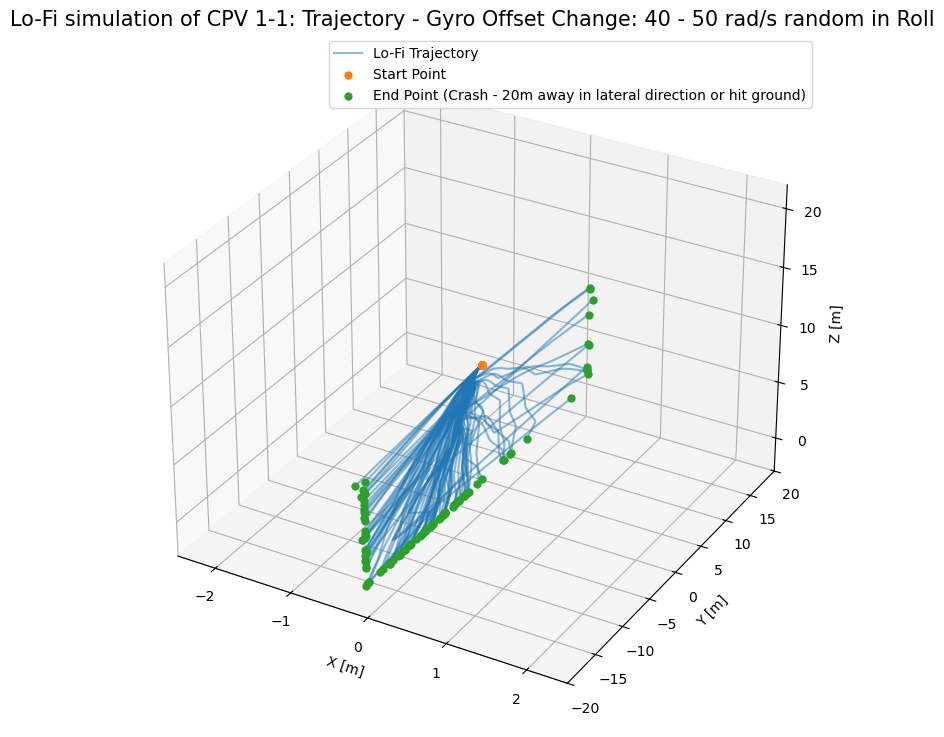

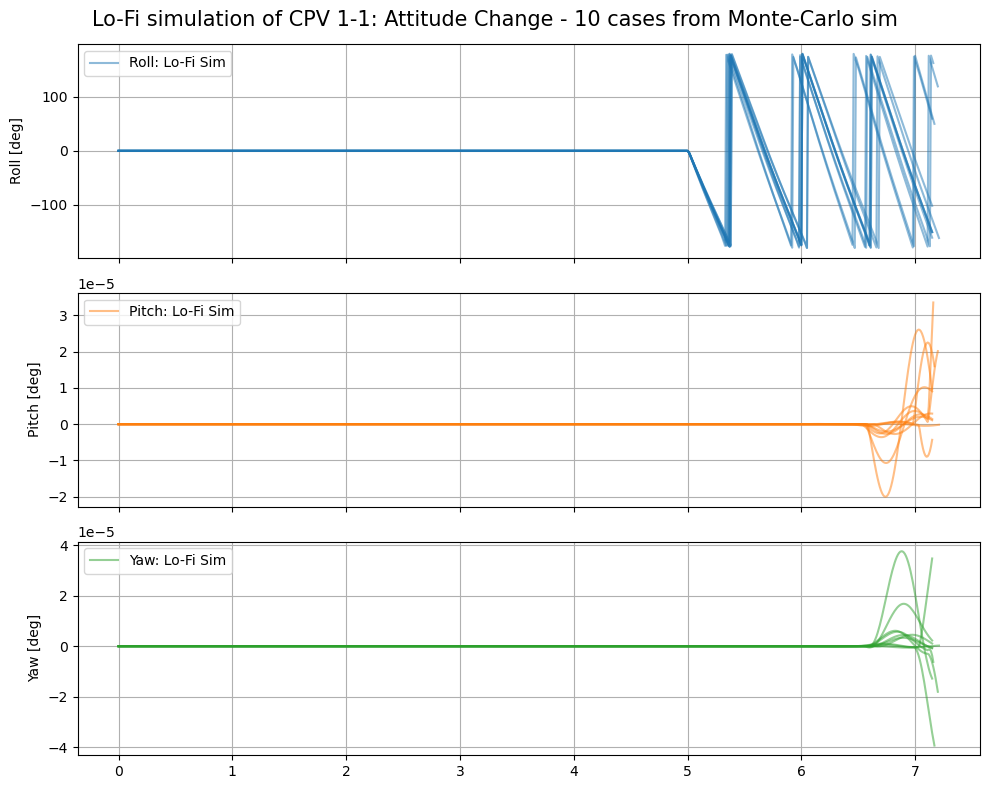

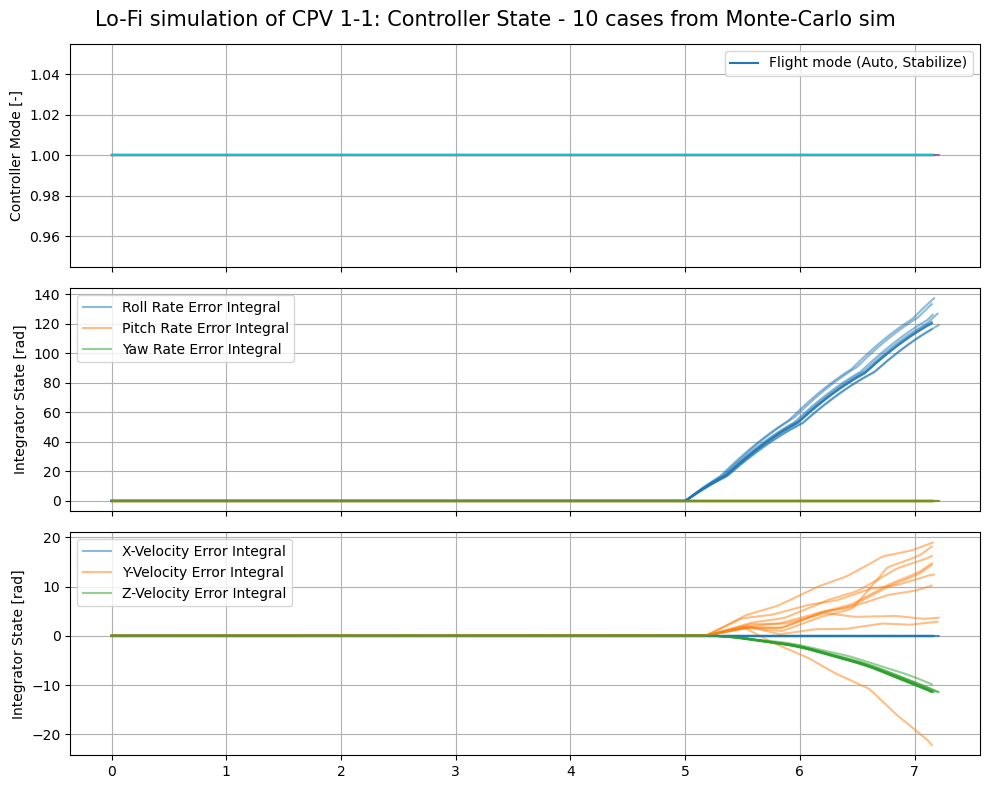

In [39]:
# CPV 1-1: gyroscope parameter change in the controller
# simulation time
t0 = 0.0
tf = 10.0
dt = 0.01 

# initialize controller state
s0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# initialize vehicle state
x0 = np.array([0, 0, -10.0, 0, 0, 0, 1.0, 0.0, 0.0, 0.0, 0, 0, 0])

# initialize control input
u0 = np.array([761.112, 761.112, 761.112, 761.112])

# initialize dynamics parameters
quad_params = np.array([1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

# initialize sensor parameters
sensor_params = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]])

# initialize controller parameters
ctrl_params = np.array([
    30/180*np.pi, 60/180*np.pi, 2*9.8, 
    4.4, 4.4, 3.4, 
    0.12, 0.012, 0.24, 
    0.12, 0.012, 0.24, 
    0.20, 0.02, 0.40, 
    0.20, 0.40, 0.00, 0.00,
    1/dt, 
    1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
    0.17, 1, -1, 1, -1, 
    45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
    5.570e-06, 0.136e-06,
    0.0, 0.0, 0.0, 
    1.0, 1.0, 1.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0, 2000, 9.8])

# altitude hold mode simulation
joystick_cmd_hist = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_hist[:,0] = 0.5
wpt_cmd_hist = np.zeros((int((tf-t0)/dt)+1,3))
wpt_cmd_hist[:,0] = 0
wpt_cmd_hist[:,1] = 0
wpt_cmd_hist[:,2] = -10

# implement Monte-Carlo simulations
n_mc = 100
cpv_num = 1
sim_log_hover_mc = []

for idx in range(n_mc):

    if cpv_num == 1:
        # create the gyro offset parameter change (CPV #1-1)
        parameter_change_attack = np.zeros((int((tf-t0)/dt)+1,ctrl_params.size))
        ta0 = 5.0
        taf = 10.0
        gyro_offset_atk_axis = 0        # axis change: np.random.randint(3)
        gyro_offset_atk_level = (np.random.rand()*600+2400)/180*np.pi
        parameter_change_attack[int(ta0/dt):int(taf/dt)+1,41+gyro_offset_atk_axis] = gyro_offset_atk_level*np.ones((int((taf-ta0)/dt)+1,))
        sensor_disruption_attack = np.zeros((int((tf-t0)/dt)+1,x0.size))
        quad_parameter_change = np.zeros((int((tf-t0)/dt)+1,quad_params.size))

    sim_log_hover = simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, True)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

# plot - enable the pop up: matplotlib.use("TkAgg") or %matplotlib qt
# data1 = np.loadtxt('output1.csv', delimiter=',')  # Load CSV as a NumPy array
# data2 = np.loadtxt('output2.csv', delimiter=',')  # Load CSV as a NumPy array

# for idx in range(data2.shape[0]):
#     data2[idx,3] = np.remainder(data2[idx,3]+180,360)-180

if cpv_num == 1:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            # ax.plot(data1[:,1],data1[:,2],data1[:,3], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Hi-Fi Trajectory')
            # ax.scatter(data1[0,1],data1[0,2],data1[0,3], color='#ff7f0e', marker='o', linewidth=1.5)
            # ax.scatter(data1[-1,1],data1[-1,2],data1[-1,3], color='#2ca02c', marker='o', linewidth=1.5)
            ax.legend()
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-20.0, 20.0)
    ax.set_zlim(-3.0, 22.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Lo-Fi simulation of CPV 1-1: Trajectory - Gyro Offset Change: 40 - 50 rad/s random in Roll', fontsize=15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
        if idx == 0:
            # axes[0].plot(data2[:,0],data2[:,1], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Roll: Hi-Fi Sim')
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Roll [deg]')
    for idx in range(int(n_mc/10)):
        axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
        if idx == 0:
            # axes[1].plot(data2[:,0],data2[:,2], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Pitch: Hi-Fi Sim')
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Pitch [deg]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
        if idx == 0:
            # axes[2].plot(data2[:,0],data2[:,3], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Yaw: Hi-Fi Sim')
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Yaw [deg]')
    fig.suptitle('Lo-Fi simulation of CPV 1-1: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Controller Mode [-]')
    for idx in range(10):
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Integrator State [rad]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Integrator State [rad]')
    fig.suptitle('Lo-Fi simulation of CPV 1-1: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

Simulation (CPV 1-2)

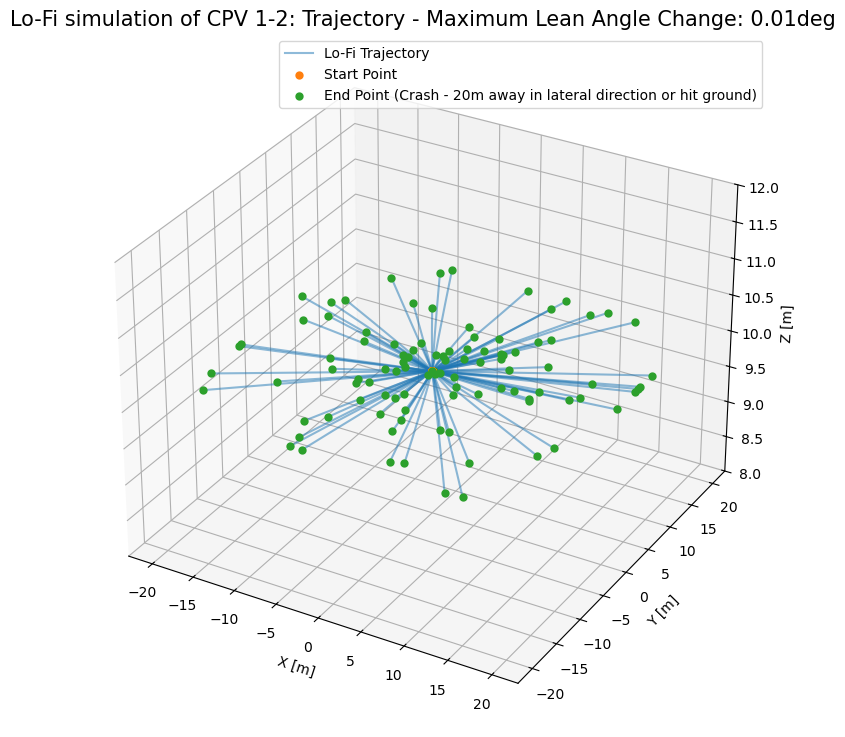

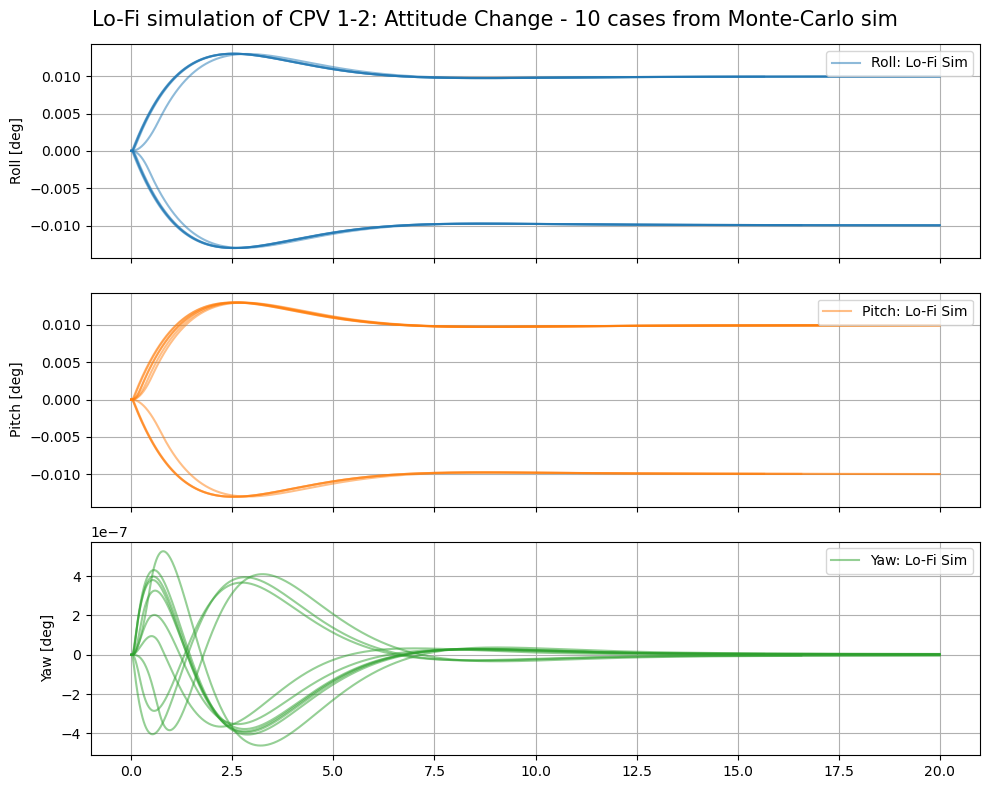

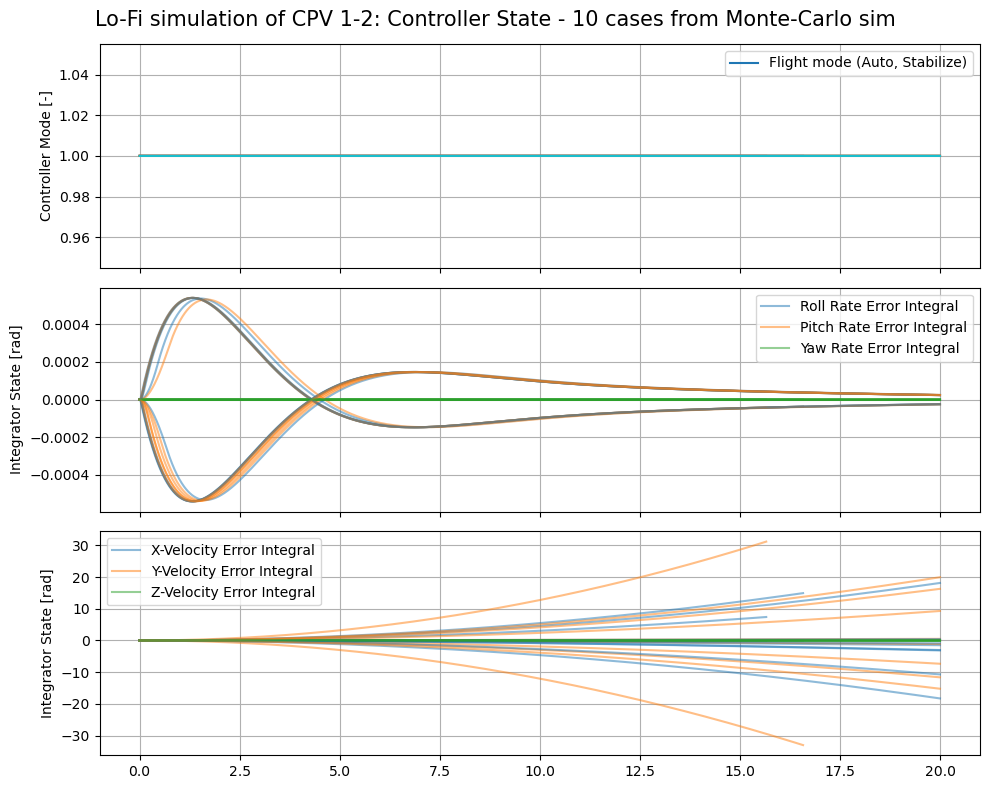

In [14]:
# CPV 1-2: maximum lean angle parameter change in the controller
# simulation time
t0 = 0.0
tf = 20.0
dt = 0.01 

# initialize controller state
s0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# initialize vehicle state
x0 = np.array([0, 0, -10.0, 0, 0, 0, 1.0, 0.0, 0.0, 0.0, 0, 0, 0])

# initialize control input
u0 = np.array([761.112, 761.112, 761.112, 761.112])

# initialize dynamics parameters
quad_params = np.array([1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

# initialize sensor parameters
sensor_params = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]])

# initialize controller parameters
ctrl_params = np.array([
    30/180*np.pi, 60/180*np.pi, 2*9.8, 
    4.4, 4.4, 3.4, 
    0.12, 0.012, 0.24, 
    0.12, 0.012, 0.24, 
    0.20, 0.02, 0.40, 
    0.20, 0.40, 0.04, 0.00,
    1/dt, 
    1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
    0.17, 1, -1, 1, -1, 
    45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
    5.570e-06, 0.136e-06,
    0.0, 0.0, 0.0, 
    1.0, 1.0, 1.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0, 2000, 9.8])

# altitude hold mode simulation
joystick_cmd_hist = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_hist[:,0] = 0.5

# implement Monte-Carlo simulations
n_mc = 100
cpv_num = 1
sim_log_hover_mc = []

for idx in range(n_mc):

    if cpv_num == 1:
        # create the maximum lean angle parameter change (CPV #1-1)
        parameter_change_attack = np.zeros((int((tf-t0)/dt)+1,ctrl_params.size))
        ta0 = 0.0
        taf = 20.0
        maximum_lean_angle_atk_level = -29.99/180*np.pi
        parameter_change_attack[int(ta0/dt):int(taf/dt)+1,0] = maximum_lean_angle_atk_level*np.ones((int((taf-ta0)/dt)+1,))
        sensor_disruption_attack = np.hstack((np.zeros((int((tf-t0)/dt)+1,x0.size-3)),0/180*np.pi*(np.random.rand(int((tf-t0)/dt)+1,3)-0.5*np.ones((int((tf-t0)/dt)+1,3)))))
        wpt_cmd_hist = np.zeros((int((tf-t0)/dt)+1,3))
        wpt_cmd_hist[:,0:2] = 0*(normalballrand(2,1,1).T*np.ones(int((tf-t0)/dt)+1)).T
        wpt_cmd_hist[:,2] = -10
        quad_parameter_change = np.zeros((int((tf-t0)/dt)+1,quad_params.size))
        quad_parameter_change[:,16:18] = 1.5*(normalballrand(2,1,1).T*np.ones(int((tf-t0)/dt)+1)).T

    sim_log_hover = simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, True)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

if cpv_num == 1:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            ax.legend()
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_zlim([8.0, 12.0])
    ax.set_title('Lo-Fi simulation of CPV 1-2: Trajectory - Maximum Lean Angle Change: 0.01deg', fontsize=15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Roll [deg]')
    for idx in range(int(n_mc/10)):
        axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Pitch [deg]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Yaw [deg]')
    fig.suptitle('Lo-Fi simulation of CPV 1-2: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Controller Mode [-]')
    for idx in range(10):
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Integrator State [rad]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Integrator State [rad]')
    fig.suptitle('Lo-Fi simulation of CPV 1-2: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

Simulation (CPV 1-3)

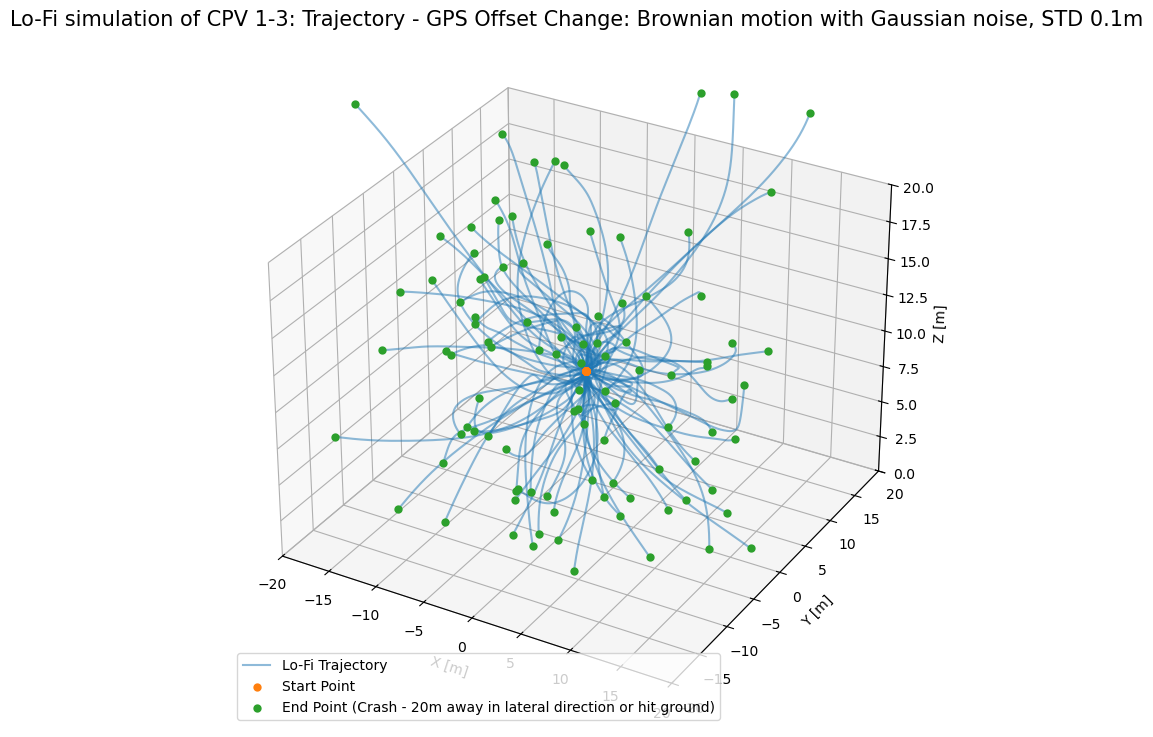

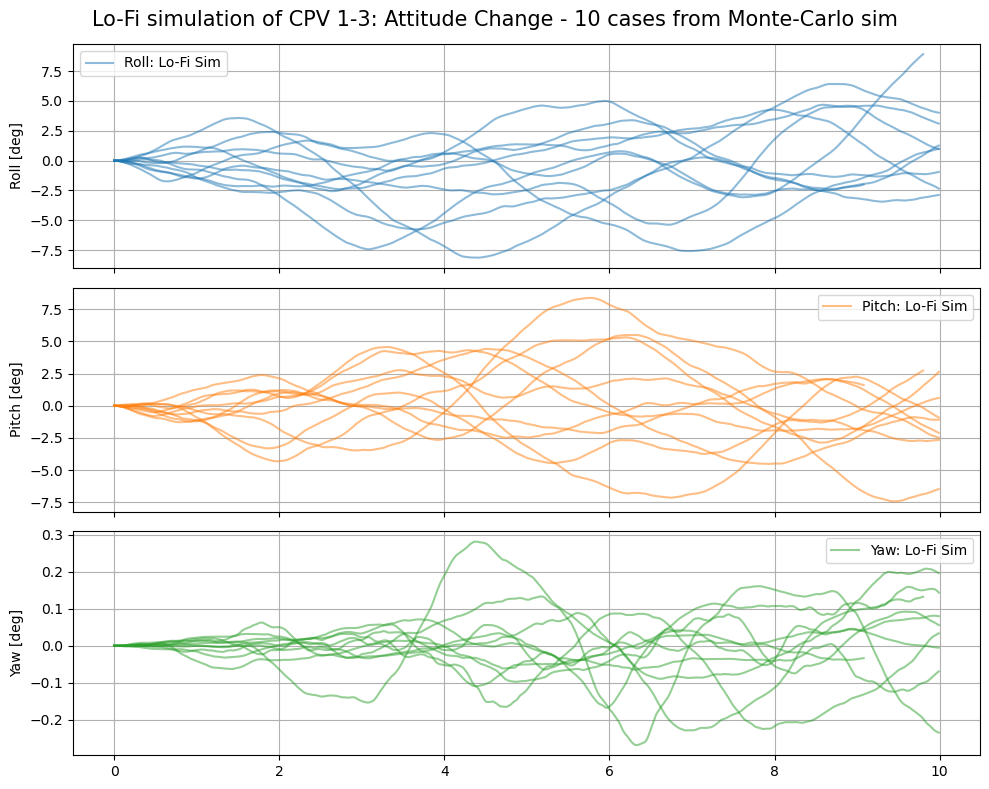

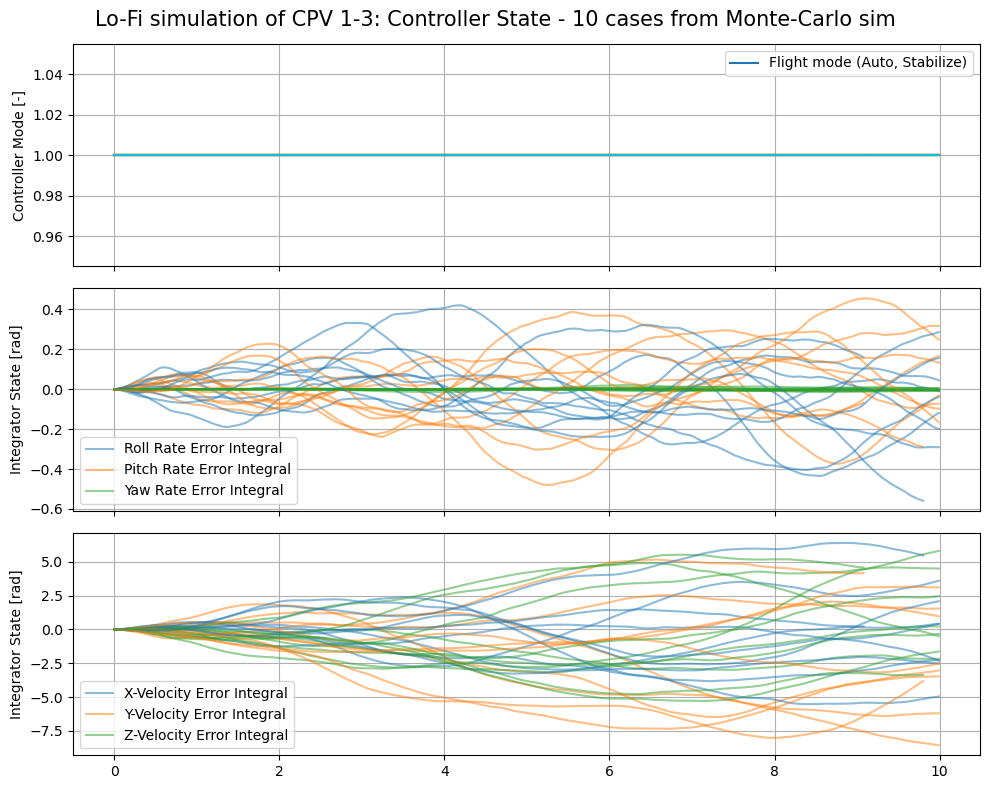

In [16]:
# CPV 1-3: gps offset change in the controller
# simulation time
t0 = 0.0
tf = 10.0
dt = 0.01 

# initialize controller state
s0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# initialize vehicle state
x0 = np.array([0, 0, -10.0, 0, 0, 0, 1.0, 0.0, 0.0, 0.0, 0, 0, 0])

# initialize control input
u0 = np.array([761.112, 761.112, 761.112, 761.112])

# initialize dynamics parameters
quad_params = np.array([1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

# initialize sensor parameters
sensor_params = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]])

# initialize controller parameters
ctrl_params = np.array([
    30/180*np.pi, 60/180*np.pi, 2*9.8, 
    4.4, 4.4, 3.4, 
    0.12, 0.012, 0.24, 
    0.12, 0.012, 0.24, 
    0.20, 0.02, 0.40, 
    0.20, 0.40, 0.00, 0.00,
    1/dt, 
    1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
    0.17, 1, -1, 1, -1, 
    45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
    5.570e-06, 0.136e-06,
    0.0, 0.0, 0.0, 
    1.0, 1.0, 1.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0, 2000, 9.8])

# altitude hold mode simulation
joystick_cmd_hist = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_hist[:,0] = 0.5
wpt_cmd_hist = np.zeros((int((tf-t0)/dt)+1,3))
wpt_cmd_hist[:,0] = 0
wpt_cmd_hist[:,1] = 0
wpt_cmd_hist[:,2] = -10

# implement Monte-Carlo simulations
n_mc = 100
cpv_num = 1
sim_log_hover_mc = []

for idx in range(n_mc):

    if cpv_num == 1:
        # create the gps offset parameter change (CPV #1-3)
        parameter_change_attack = np.zeros((int((tf-t0)/dt)+1,ctrl_params.size))
        ta0 = 0.0
        taf = 10.0
        gps_offset_attack_noise_level = 0.5
        for idx_sub in range(int(ta0/dt),int(taf/dt)+1,1):
            parameter_change_attack[idx_sub,47:50] = parameter_change_attack[idx_sub-1,47:50]+gps_offset_attack_noise_level*np.random.randn(3)
        sensor_disruption_attack = np.zeros((int((tf-t0)/dt)+1,x0.size))
        quad_parameter_change = np.zeros((int((tf-t0)/dt)+1,quad_params.size))

    sim_log_hover = simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, True)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

if cpv_num == 1:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            ax.legend()
    ax.set_xlim(-20.0, 20.0)
    ax.set_ylim(-20.0, 20.0)
    ax.set_zlim(0.0, 20.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Lo-Fi simulation of CPV 1-3: Trajectory - GPS Offset Change: Brownian motion with Gaussian noise, STD 0.1m', fontsize=15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Roll [deg]')
    for idx in range(int(n_mc/10)):
        axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Pitch [deg]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Yaw [deg]')
    fig.suptitle('Lo-Fi simulation of CPV 1-3: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Controller Mode [-]')
    for idx in range(10):
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Integrator State [rad]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Integrator State [rad]')
    fig.suptitle('Lo-Fi simulation of CPV 1-3: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

Simulation (CPV 3)

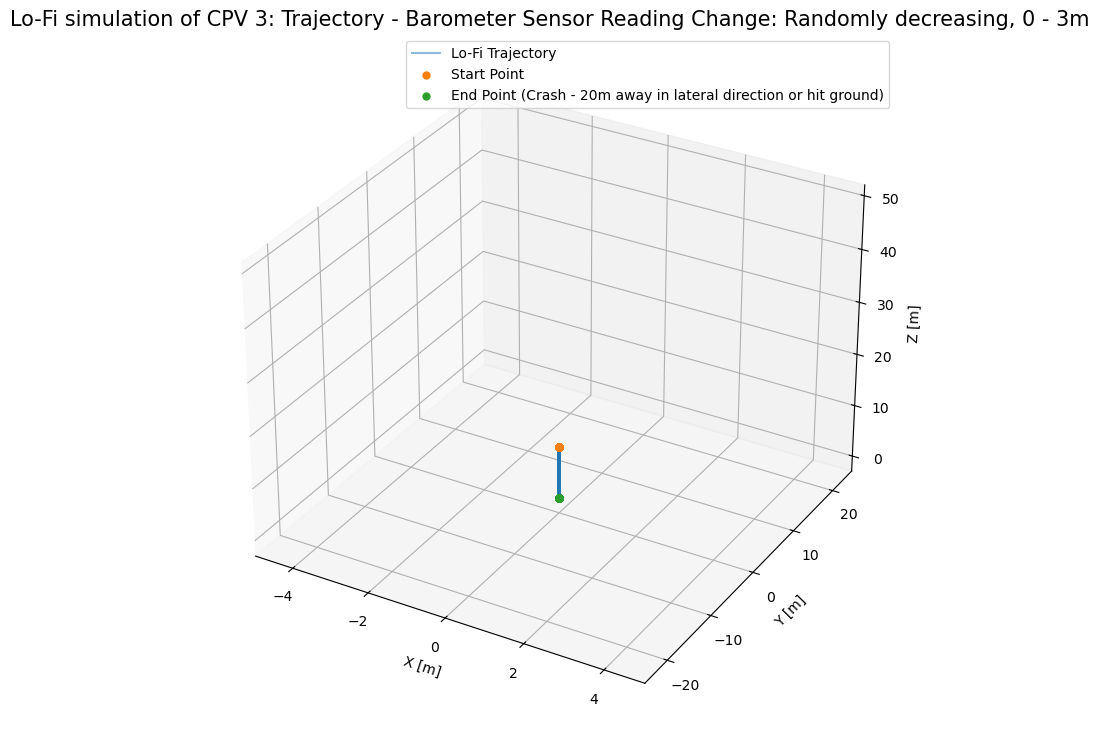

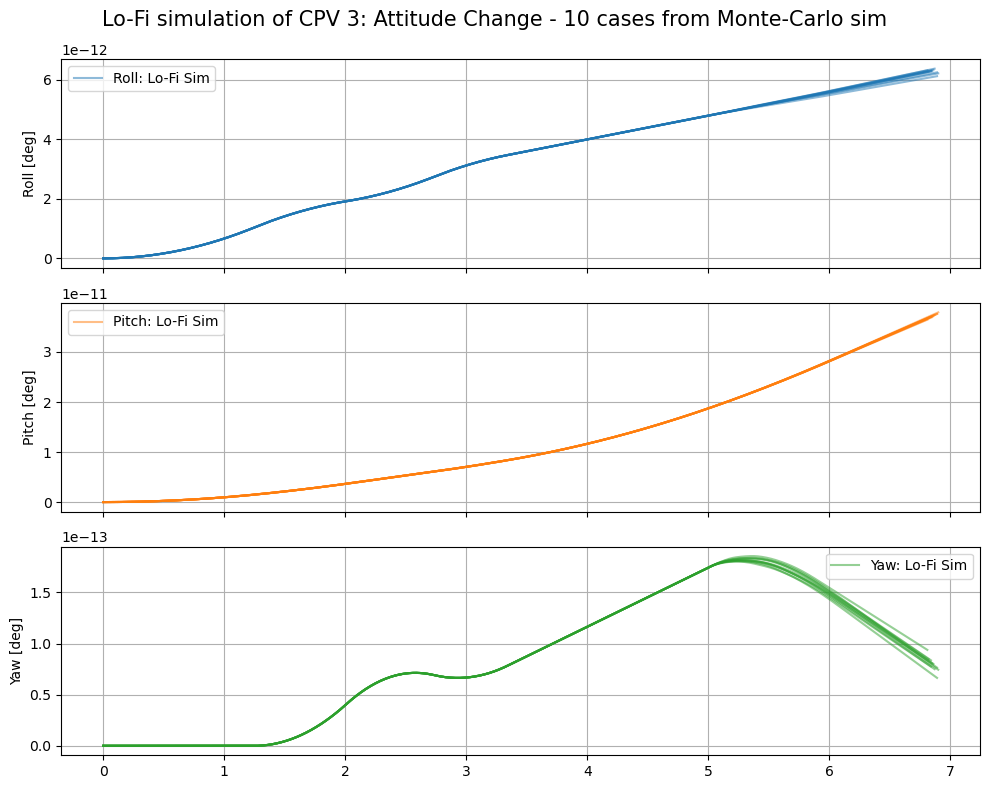

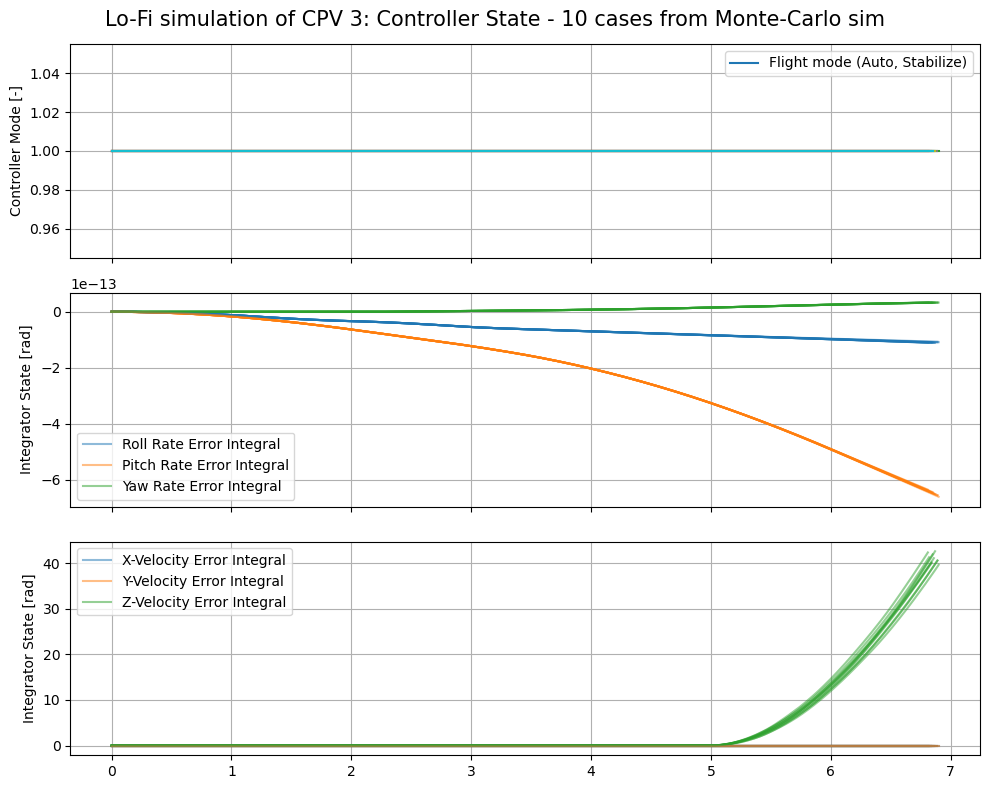

In [17]:
# CPV 3: barometer sensor value change in the controller
# simulation time
t0 = 0.0
tf = 20.0
dt = 0.01 

# initialize controller state
s0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# initialize vehicle state
x0 = np.array([0, 0, -10.0, 0, 0, 0, 1.0, 0.0, 0.0, 0.0, 0, 0, 0])

# initialize control input
u0 = np.array([761.112, 761.112, 761.112, 761.112])

# initialize dynamics parameters
quad_params = np.array([1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

# initialize sensor parameters
sensor_params = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]])

# initialize controller parameters
ctrl_params = np.array([
    30/180*np.pi, 60/180*np.pi, 2*9.8, 
    4.4, 4.4, 3.4, 
    0.12, 0.012, 0.24, 
    0.12, 0.012, 0.24, 
    0.20, 0.02, 0.40, 
    0.20, 0.40, 0.00, 0.00,
    1/dt, 
    1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
    0.17, 1, -1, 1, -1, 
    45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
    5.570e-06, 0.136e-06,
    0.0, 0.0, 0.0, 
    1.0, 1.0, 1.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0, 2000, 9.8])

# altitude hold mode simulation
joystick_cmd_hist = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_hist[:,0] = 0.5
wpt_cmd_hist = np.zeros((int((tf-t0)/dt)+1,3))
wpt_cmd_hist[:,0] = 0
wpt_cmd_hist[:,1] = 0
wpt_cmd_hist[:,2] = -10

# implement Monte-Carlo simulations
n_mc = 100
cpv_num = 3
sim_log_hover_mc = []

for idx in range(n_mc):

    if cpv_num == 3:
        # create the barometer sensor value change (CPV #3)
        parameter_change_attack = np.zeros((int((tf-t0)/dt)+1,ctrl_params.size))
        ta0 = 5.0
        taf = 10.0
        baro_sensor_attack_noise_level = -3.0
        sensor_disruption_attack = np.zeros((int((tf-t0)/dt)+1,x0.size))
        for idx_sub in range(int(ta0/dt),int(taf/dt)+1,1):
            sensor_disruption_attack[idx_sub,2] = sensor_disruption_attack[idx_sub-1,2]+baro_sensor_attack_noise_level*np.random.rand()
        quad_parameter_change = np.zeros((int((tf-t0)/dt)+1,quad_params.size))

    sim_log_hover = simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, True)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

if cpv_num == 3:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            ax.legend()
    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(-25.0, 25.0)
    ax.set_zlim(-3.0, 52.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Lo-Fi simulation of CPV 3: Trajectory - Barometer Sensor Reading Change: Randomly decreasing, 0 - 3m', fontsize=15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Roll [deg]')
    for idx in range(int(n_mc/10)):
        axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Pitch [deg]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Yaw [deg]')
    fig.suptitle('Lo-Fi simulation of CPV 3: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Controller Mode [-]')
    for idx in range(10):
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Integrator State [rad]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Integrator State [rad]')
    fig.suptitle('Lo-Fi simulation of CPV 3: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

Simulation (CPV 4)

In [18]:
# CPV 4: gyroscope acoustic noise injection
# simulation time
t0 = 0.0
tf = 20.0
dt = 0.01 

# initialize controller state
s0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# initialize vehicle state
x0 = np.array([0, 0, -10.0, 0, 0, 0, 1.0, 0.0, 0.0, 0.0, 0, 0, 0])

# initialize control input
u0 = np.array([761.112, 761.112, 761.112, 761.112])

# initialize dynamics parameters
quad_params = np.array([1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 0.17, 1, -1, 1, -1, 45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 5.570e-06, 0.136e-06, 9.8, 0.0, 0.0, 0.0])

# initialize sensor parameters
sensor_params = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]])

# initialize controller parameters
ctrl_params = np.array([
    30/180*np.pi, 60/180*np.pi, 2*9.8, 
    4.4, 4.4, 3.4, 
    0.12, 0.012, 0.24, 
    0.12, 0.012, 0.24, 
    0.20, 0.02, 0.40, 
    0.20, 0.40, 0.00, 0.00,
    1/dt, 
    1.3170, 6.5e-3, 6.8e-3, 1.32e-2, 
    0.17, 1, -1, 1, -1, 
    45/180*np.pi, 135/180*np.pi, 225/180*np.pi, 315/180*np.pi, 
    5.570e-06, 0.136e-06,
    0.0, 0.0, 0.0, 
    1.0, 1.0, 1.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 
    0, 2000, 9.8])

# altitude hold mode simulation
joystick_cmd_hist = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_hist[:,0] = 0.5
wpt_cmd_hist = np.zeros((int((tf-t0)/dt)+1,3))
wpt_cmd_hist[:,0] = 0
wpt_cmd_hist[:,1] = 0
wpt_cmd_hist[:,2] = -10

# implement Monte-Carlo simulations
n_mc = 100
cpv_num = 4
sim_log_hover_mc = []

for idx in range(n_mc):

    if cpv_num == 4:
        # create the acoustic noise injection (CPV #4)
        parameter_change_attack = np.zeros((int((tf-t0)/dt)+1,ctrl_params.size))
        ta0 = 5.0
        taf = 10.0
        baro_sensor_attack_noise_level = -3.0
        sensor_disruption_attack = np.zeros((int((tf-t0)/dt)+1,x0.size))
        d_axis = [0,1,2]
        d_level = 130/180*np.pi
        for idx_sub in range(int(ta0/dt),int(taf/dt)+1,1):
            sensor_disruption_attack[idx_sub,10:13] = normalballrand(len(d_axis),d_level,int((taf-ta0)/dt)+1)
        quad_parameter_change = np.zeros((int((tf-t0)/dt)+1,quad_params.size))

    sim_log_hover = simulate(t0, tf, dt, s0, x0, u0, quad_params, sensor_params, ctrl_params, joystick_cmd_hist, wpt_cmd_hist, parameter_change_attack, sensor_disruption_attack, quad_parameter_change, True)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

if cpv_num == 4:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            ax.legend()
    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(-25.0, 25.0)
    ax.set_zlim(-3.0, 52.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Lo-Fi simulation of CPV 3: Trajectory - Barometer Sensor Reading Change: Randomly decreasing, 0 - 3m', fontsize=15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Roll [deg]')
    for idx in range(int(n_mc/10)):
        axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Pitch [deg]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Yaw [deg]')
    fig.suptitle('Lo-Fi simulation of CPV 3: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for idx in range(int(n_mc/10)):
        axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
        if idx == 0:
            axes[0].legend()
    axes[0].grid()
    axes[0].set_ylabel('Controller Mode [-]')
    for idx in range(10):
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
        axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[1].legend()
    axes[1].grid()
    axes[1].set_ylabel('Integrator State [rad]')
    for idx in range(int(n_mc/10)):
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
        axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
        if idx == 0:
            axes[2].legend()
    axes[2].grid()
    axes[2].set_ylabel('Integrator State [rad]')
    fig.suptitle('Lo-Fi simulation of CPV 3: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)
    plt.tight_layout()

ValueError: could not broadcast input array from shape (501,3) into shape (3,)

Do not use

In [68]:
# CPV 1-1
# simulation under distrubances given to gyroscope by ultrasound (simple)
t0 = 0.0
tf = 20.0
dt = 0.01 

# implement Monte-Carlo simulations
n_mc = 50
cpv_num = 1
sim_log_hover_mc = []

# hover simulation
joystick_cmd_h = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_h[:,0] = 0.5
wpt_cmd = np.zeros((int((tf-t0)/dt)+1,3))
wpt_cmd[:,0] = 0
wpt_cmd[:,1] = 0
wpt_cmd[:,2] = -10

for idx in range(n_mc):

    if cpv_num == 4:
        # create the random gyro disturbance (CPV #4)
        gyro_dist_rnd = np.zeros((int((tf-t0)/dt)+1,3))
        td0 = 5.0
        tdf = 15.0
        d_axis = [0,1,2]
        d_level = 130/180*np.pi
        gyro_dist_rnd[int(td0/dt):int(tdf/dt)+1,d_axis] = normalballrand(len(d_axis),d_level,int((tdf-td0)/dt)+1)
    else:
        gyro_dist_rnd = np.zeros((int((tf-t0)/dt)+1,3))

    if cpv_num == 1:
        # create the gyro offset parameter change (CPV #1)
        gyro_offset_atk = np.zeros((int((tf-t0)/dt)+1,3))
        ta0 = 6.3
        taf = 10.0
        gyro_offset_atk_axis = 0        # axis change: np.random.randint(3)
        gyro_offset_atk_level = (np.random.rand()*600+2400)/180*np.pi
        gyro_offset_atk[int(ta0/dt):int(taf/dt)+1,gyro_offset_atk_axis] = gyro_offset_atk_level*np.ones((int((taf-ta0)/dt)+1,))
    else:
        gyro_offset_atk = np.zeros((int((tf-t0)/dt)+1,3))

    sim_log_hover = simulate(t0, tf, dt, joystick_cmd_h, wpt_cmd, gyro_dist_rnd, gyro_offset_atk, False)
    sim_log_hover['rpy'] = np.zeros((np.shape(sim_log_hover['x'])[0],3))

    for idx in range(np.shape(sim_log_hover['rpy'])[0]):
        sim_log_hover['rpy'][idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()/np.pi*180

    sim_log_hover_mc.append(sim_log_hover)

# plot - enable the pop up: matplotlib.use("TkAgg") or %matplotlib qt
%matplotlib qt
data1 = np.loadtxt('output1.csv', delimiter=',')  # Load CSV as a NumPy array
data2 = np.loadtxt('output2.csv', delimiter=',')  # Load CSV as a NumPy array

for idx in range(data2.shape[0]):
    data2[idx,3] = np.remainder(data2[idx,3]+180,360)-180

if cpv_num == 4:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='3D Trajectory (Hover)')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        if idx == 0:
            ax.legend()
    ax.set_xlim(-20.0, 20.0)
    ax.set_ylim(-20.0, 20.0)
    ax.set_zlim(5.0, 25.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    plt.show()

if cpv_num == 1:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Lo-Fi Trajectory')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)')
        if idx == 0:
            ax.plot(data1[:,1],data1[:,2],data1[:,3], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Hi-Fi Trajectory')
            ax.scatter(data1[0,1],data1[0,2],data1[0,3], color='#ff7f0e', marker='o', linewidth=1.5)
            ax.scatter(data1[-1,1],data1[-1,2],data1[-1,3], color='#2ca02c', marker='o', linewidth=1.5)
            ax.legend()
    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(-25.0, 25.0)
    ax.set_zlim(-3.0, 52.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Lo-Fi simulation of CPV 1: Trajectory - Gyro Offset Change: 40 - 50 rad/s random in Roll', fontsize=15)

if cpv_num == 0:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    for idx in range(n_mc):
        ax.plot(sim_log_hover_mc[idx]['x'][:,0], sim_log_hover_mc[idx]['x'][:,1], -sim_log_hover_mc[idx]['x'][:,2], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='3D Trajectory (Hover)')
        ax.scatter(sim_log_hover_mc[idx]['x'][0,0], sim_log_hover_mc[idx]['x'][0,1], -sim_log_hover_mc[idx]['x'][0,2], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
        ax.scatter(sim_log_hover_mc[idx]['x'][-1,0], sim_log_hover_mc[idx]['x'][-1,1], -sim_log_hover_mc[idx]['x'][-1,2], color='#2ca02c', marker='o', linewidth=1.5, label='End Point (Crash - 20m away in lateral direction or hit ground)') 
        if idx == 0:
            ax.legend()
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for idx in range(10):
    axes[0].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 0], label='Roll: Lo-Fi Sim',alpha=0.5,color='#1f77b4')
    if idx == 0:
        axes[0].plot(data2[:,0],data2[:,1], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Roll: Hi-Fi Sim')
        axes[0].legend()
axes[0].grid()
axes[0].set_ylabel('Roll [deg]')
for idx in range(10):
    axes[1].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 1], label='Pitch: Lo-Fi Sim',alpha=0.5,color='#ff7f0e')
    if idx == 0:
        axes[1].plot(data2[:,0],data2[:,2], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Pitch: Hi-Fi Sim')
        axes[1].legend()
axes[1].grid()
axes[1].set_ylabel('Pitch [deg]')
for idx in range(10):
    axes[2].plot(sim_log_hover_mc[idx]['t'], sim_log_hover_mc[idx]['rpy'][:-1, 2], label='Yaw: Lo-Fi Sim',alpha=0.5,color='#2ca02c')
    if idx == 0:
        axes[2].plot(data2[:,0],data2[:,3], color='#d62728', linestyle='-', linewidth=1.5, alpha=1.0, label='Yaw: Hi-Fi Sim')
        axes[2].legend()
axes[2].grid()
axes[2].set_ylabel('Yaw [deg]')
fig.suptitle('Lo-Fi simulation of CPV 1: Attitude Change - 10 cases from Monte-Carlo sim', fontsize=15)
plt.tight_layout()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for idx in range(10):
    axes[0].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,0],label='Flight mode (Auto, Stabilize)')
    if idx == 0:
        axes[0].legend()
axes[0].grid()
axes[0].set_ylabel('Controller Mode [-]')
for idx in range(10):
    axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,5],label='Roll Rate Error Integral',alpha=0.5,color='#1f77b4')
    axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,6],label='Pitch Rate Error Integral',alpha=0.5,color='#ff7f0e')
    axes[1].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,7],label='Yaw Rate Error Integral',alpha=0.5,color='#2ca02c')
    if idx == 0:
        axes[1].legend()
axes[1].grid()
axes[1].set_ylabel('Integrator State [rad]')
for idx in range(10):
    axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,11],label='X-Velocity Error Integral',alpha=0.5,color='#1f77b4')
    axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,12],label='Y-Velocity Error Integral',alpha=0.5,color='#ff7f0e')
    axes[2].plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,13],label='Z-Velocity Error Integral',alpha=0.5,color='#2ca02c')
    if idx == 0:
        axes[2].legend()
axes[2].grid()
axes[2].set_ylabel('Integrator State [rad]')
fig.suptitle('Lo-Fi simulation of CPV 1: Controller State - 10 cases from Monte-Carlo sim', fontsize=15)



# plt.figure(figsize=(10, 5))
# for idx in range(n_mc):
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['x'][:-1,3],label='Body U-velocity')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['x'][:-1,4],label='Body V-velocity')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['x'][:-1,5],label='Body W-velocity')
#     if idx == 0:
#         plt.legend()
# plt.grid()
# plt.xlabel('TIME [sec]')
# plt.ylabel('VEL [m/s]')

# plt.figure(figsize=(10, 5))
# for idx in range(n_mc):
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,8],label='X-position error')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,9],label='Y-position error')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['s'][:-1,10],label='Z-position error')
#     if idx == 0:
#         plt.legend()
# plt.grid()
# plt.xlabel('TIME [sec]')
# plt.ylabel('ERR [m]')

# plt.figure(figsize=(10, 5))
# for idx in range(n_mc):
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['u'][:,0],label='Top-Right')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['u'][:,1],label='Bottom-Right')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['u'][:,2],label='Bottom-Left')
#     plt.plot(sim_log_hover_mc[idx]['t'],sim_log_hover_mc[idx]['u'][:,3],label='Top-Left')
#     if idx == 0:
#         plt.legend()
# plt.grid()
# plt.xlabel('TIME [sec]')
# plt.ylabel('ROTOR [rad/s]')




# plt.figure(figsize=(10, 5))
# plt.plot(sim_log_hover['t'],gyro_dist_rnd[:-1,0]/np.pi*180,label='Roll disturbance')
# plt.plot(sim_log_hover['t'],gyro_dist_rnd[:-1,1]/np.pi*180,label='Pitch disturbance')
# plt.plot(sim_log_hover['t'],gyro_dist_rnd[:-1,2]/np.pi*180,label='Yaw disturbance')
# plt.legend()
# plt.grid()
# plt.xlabel('TIME [sec]')
# plt.ylabel('RATE [deg/s]')

TypeError: simulate() missing 5 required positional arguments: 'ctrl_params', 'joystick_cmd_hist', 'wpt_cmd_hist', 'parameter_change_attack', and 'sensor_disruption_attack'

Joystick command simulations (Not updated)

Text(0, 0.5, 'ATT [deg]')

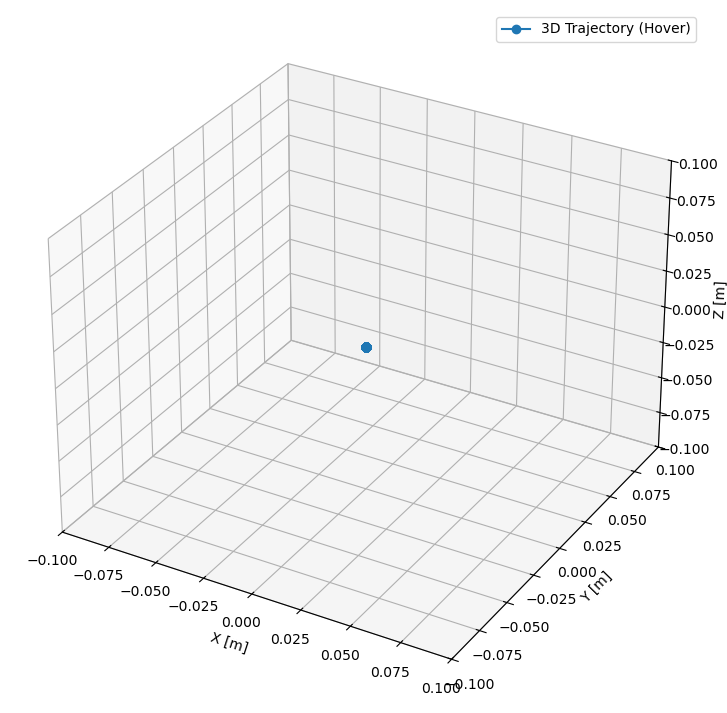

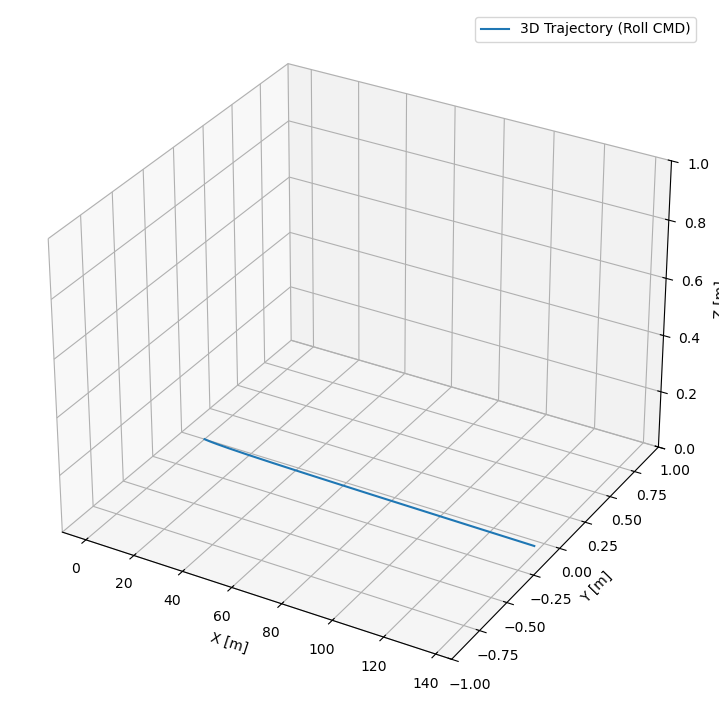

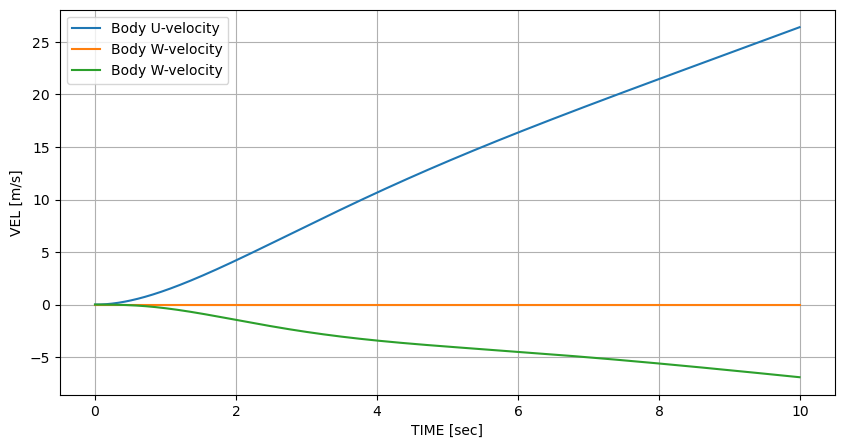

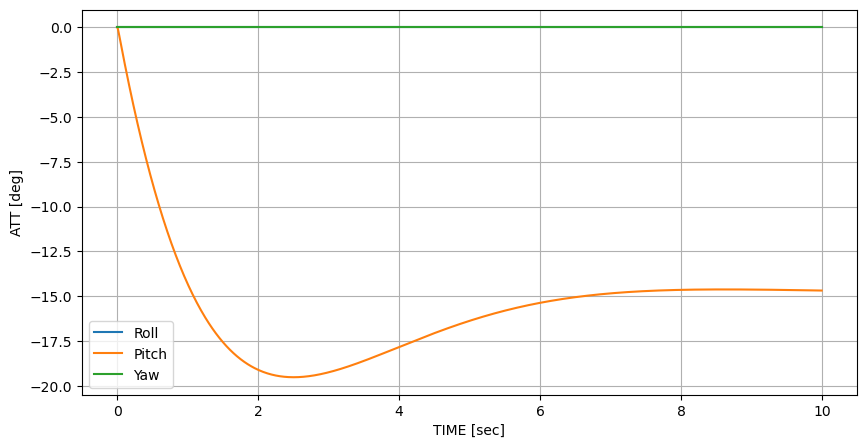

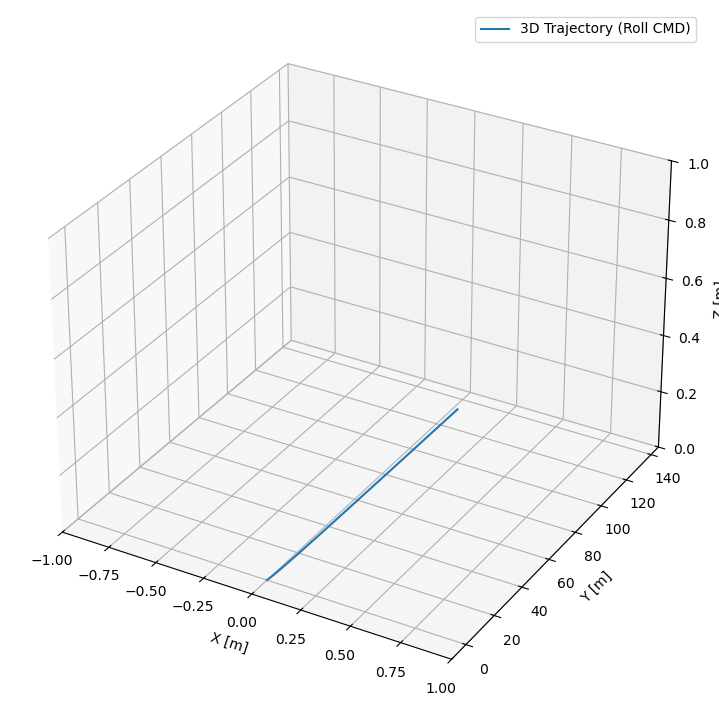

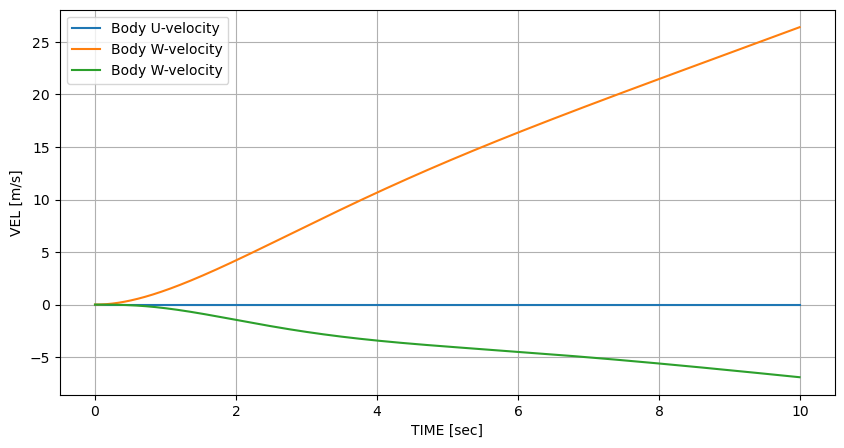

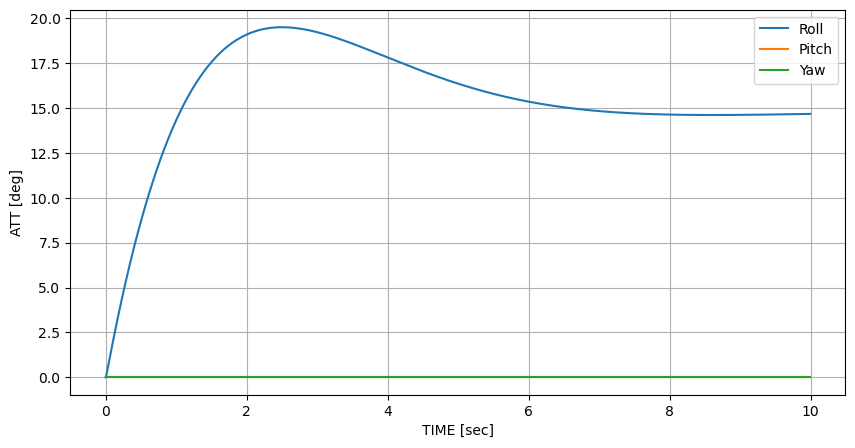

In [ ]:
# simulations using different joystick command history
t0 = 0.0
tf = 10.0
dt = 0.01 

# hover simulation
joystick_cmd_h = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_h[:,0] = 0.5
joystick_cmd_h[:,1] = 0.0

sim_log_hover = simulate(t0, tf, dt, joystick_cmd_h)

sim_log_hover_rpy = np.zeros((int((tf-t0)/dt)+1,3))
for idx in range(int((tf-t0)/dt)+1):
    sim_log_hover_rpy[idx] = quat2eul(sim_log_hover['x'][idx,6:10]).toarray().flatten()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sim_log_hover['x'][:,0], sim_log_hover['x'][:,1], -sim_log_hover['x'][:,2], marker='o', linestyle='-', linewidth=1.5, label='3D Trajectory (Hover)')
ax.legend()
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(-0.1, 0.1)
ax.set_zlim(-0.1, 0.1)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

# pitch -15deg simulation
joystick_cmd_p = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_p[:,0] = 0.5
joystick_cmd_p[:,2] = -0.5

sim_log_pit = simulate(t0, tf, dt, joystick_cmd_p)

sim_log_pit_rpy = np.zeros((int((tf-t0)/dt)+1,3))
for idx in range(int((tf-t0)/dt)+1):
    sim_log_pit_rpy[idx] = quat2eul(sim_log_pit['x'][idx,6:10]).toarray().flatten()/np.pi*180

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sim_log_pit['x'][:,0], sim_log_pit['x'][:,1], -sim_log_pit['x'][:,2], linestyle='-', linewidth=1.5, label='3D Trajectory (Roll CMD)')
ax.legend()
ax.set_ylim(-1.0, 1.0)
ax.set_zlim(0.0, 1.0)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

plt.figure(figsize=(10, 5))
plt.plot(sim_log_pit['t'],sim_log_pit['x'][:-1,3],label='Body U-velocity')
plt.plot(sim_log_pit['t'],sim_log_pit['x'][:-1,4],label='Body W-velocity')
plt.plot(sim_log_pit['t'],sim_log_pit['x'][:-1,5],label='Body W-velocity')
plt.legend()
plt.grid()
plt.xlabel('TIME [sec]')
plt.ylabel('VEL [m/s]')

plt.figure(figsize=(10, 5))
plt.plot(sim_log_pit['t'],sim_log_pit_rpy[:-1,0],label='Roll')
plt.plot(sim_log_pit['t'],sim_log_pit_rpy[:-1,1],label='Pitch')
plt.plot(sim_log_pit['t'],sim_log_pit_rpy[:-1,2],label='Yaw')
plt.legend()
plt.grid()
plt.xlabel('TIME [sec]')
plt.ylabel('ATT [deg]')

# roll 15deg simulation
joystick_cmd_r = np.zeros((int((tf-t0)/dt)+1,4))
joystick_cmd_r[:,0] = 0.5
joystick_cmd_r[:,1] = 0.5

sim_log_rll = simulate(t0, tf, dt, joystick_cmd_r)

sim_log_rll_rpy = np.zeros((int((tf-t0)/dt)+1,3))
for idx in range(int((tf-t0)/dt)+1):
    sim_log_rll_rpy[idx] = quat2eul(sim_log_rll['x'][idx,6:10]).toarray().flatten()/np.pi*180

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sim_log_rll['x'][:,0], sim_log_rll['x'][:,1], -sim_log_rll['x'][:,2], linestyle='-', linewidth=1.5, label='3D Trajectory (Roll CMD)')
ax.legend()
ax.set_xlim(-1.0, 1.0)
ax.set_zlim(0.0, 1.0)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

plt.figure(figsize=(10, 5))
plt.plot(sim_log_rll['t'],sim_log_rll['x'][:-1,3],label='Body U-velocity')
plt.plot(sim_log_rll['t'],sim_log_rll['x'][:-1,4],label='Body W-velocity')
plt.plot(sim_log_rll['t'],sim_log_rll['x'][:-1,5],label='Body W-velocity')
plt.legend()
plt.grid()
plt.xlabel('TIME [sec]')
plt.ylabel('VEL [m/s]')

plt.figure(figsize=(10, 5))
plt.plot(sim_log_rll['t'],sim_log_rll_rpy[:-1,0],label='Roll')
plt.plot(sim_log_rll['t'],sim_log_rll_rpy[:-1,1],label='Pitch')
plt.plot(sim_log_rll['t'],sim_log_rll_rpy[:-1,2],label='Yaw')
plt.legend()
plt.grid()
plt.xlabel('TIME [sec]')
plt.ylabel('ATT [deg]')